### Ejercicios

**Ejercicio:** Dado un conjunto de valores $x_1, x_2, ..., x_N$
1. ¿Qué valor $x$ minimiza el error cuadrático ($\sum_{i=1}^{N} (x_i - x)^2$)?
1. ¿Y si el error es absoluto ($\sum_{i=1}^{N} |x_i - x|$)?


#### Resolución

**1. Error cuadrático**

Sea $f(x) = \sum_{i=1}^{N} (x_i - x)^2$. Es una función diferenciable y estrictamente convexa en $x$ (suma de parábolas convexas), por lo que su único punto crítico es un mínimo global. Derivando e igualando a cero:

$$\frac{df}{dx} = -2\sum_{i=1}^{N}(x_i - x) = 0 \;\Longrightarrow\; \sum_{i=1}^{N} x_i = N x \;\Longrightarrow\; x^\star = \frac{1}{N}\sum_{i=1}^N x_i = \bar{x}$$

Como $f''(x) = 2N > 0$, se confirma que es un mínimo. **El valor que minimiza el error cuadrático es la media muestral $\bar{x}$.**

**2. Error absoluto**

Sea $g(x) = \sum_{i=1}^{N} |x_i - x|$. Es convexa pero no diferenciable en los puntos $x = x_i$. Para $x \neq x_i \; \forall i$, la derivada es

$$\frac{dg}{dx} = -\sum_{i=1}^{N} \operatorname{sign}(x_i - x) = \#\{i : x_i < x\} - \#\{i : x_i > x\}$$

Entre dos valores consecutivos del conjunto ordenado, $g$ es lineal con esta pendiente constante (un entero). La pendiente pasa de negativa a positiva exactamente cuando el número de puntos a la izquierda iguala (o casi iguala) al número de puntos a la derecha, es decir, en la **mediana** de los datos.

- Si $N$ es impar, el mínimo es único y se alcanza en el valor central $x_{((N+1)/2)}$.
- Si $N$ es par, la pendiente es exactamente $0$ en todo el intervalo $[x_{(N/2)}, x_{(N/2+1)}]$, por lo que **cualquier valor en ese intervalo** (no solo el punto medio) minimiza $g$.

**El valor que minimiza el error absoluto es la mediana muestral** (en general, no necesariamente única). Esto ilustra una propiedad importante: la media es sensible a *outliers* (porque el error cuadrático penaliza fuerte las desviaciones grandes), mientras que la mediana es robusta frente a ellos.

A continuación se verifica numéricamente con un ejemplo con outliers.

In [1]:
import numpy as np

rng = np.random.default_rng(42)
x = np.concatenate([rng.normal(10, 1, 20), [100.0]])  # con un outlier

grid = np.linspace(x.min() - 1, x.max() + 1, 20000)
sq_error = [(np.sum((x - c) ** 2)) for c in grid]
abs_error = [(np.sum(np.abs(x - c))) for c in grid]

x_sq = grid[np.argmin(sq_error)]
x_abs = grid[np.argmin(abs_error)]

print(f"Media muestral            : {x.mean():.4f}")
print(f"x que minimiza el cuadrático (grilla): {x_sq:.4f}")
print(f"Mediana muestral          : {np.median(x):.4f}")
print(f"x que minimiza el absoluto (grilla)  : {x_abs:.4f}")


Media muestral            : 14.2544
x que minimiza el cuadrático (grilla): 14.2554
Mediana muestral          : 10.1278
x que minimiza el absoluto (grilla)  : 10.1260


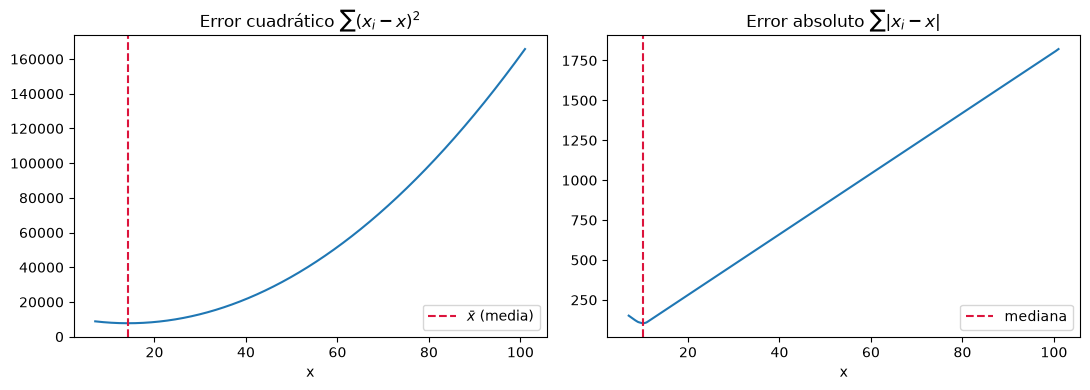

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(grid, sq_error)
axes[0].axvline(x.mean(), color="crimson", ls="--", label=r"$\bar{x}$ (media)")
axes[0].set_title(r"Error cuadrático $\sum (x_i-x)^2$")
axes[0].set_xlabel("x"); axes[0].legend()

axes[1].plot(grid, abs_error)
axes[1].axvline(np.median(x), color="crimson", ls="--", label="mediana")
axes[1].set_title(r"Error absoluto $\sum |x_i-x|$")
axes[1].set_xlabel("x"); axes[1].legend()
plt.tight_layout()
plt.show()


---

**Ejercicio:** Considerar el caso para una única variable predictora $X_1$:
1. Escribir la función de costo $RSS(\beta)$ sin usar la notación matricial. ¿Cuántas componentes tiene $\beta$?
1. Expandir la expresión y mostrar que es una función cuadrática en $\beta$.
1. Encontrar el mínimo de la función cuadrática y mostrar que se obtiene la solución de mínimos cuadrados:

$$ \hat{\beta_1} = \frac{\sum_{i=1}^{N} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{N} (x_i - \bar{x})^2}$$

$$ \hat{\beta_0} = \bar{y} - \hat{\beta_1} \bar{x}$$

1. ¿Cómo se modifican esas expresiones si consideramos predictores estandarizados?¿Y si la variable de respuesta también está estandarizada?
4. Plantear la expresión para el caso de $p = 2$ variables predictoras. ¿Cuántas componentes tiene $\beta$? ¿Cuántas ecuaciones hay que resolver para encontrar la solución de mínimos cuadrados? Reflexionar sobre la ventaja de usar la formulación matricial.


#### Resolución

**1. Función de costo sin notación matricial**

El modelo de regresión lineal simple es $\hat{y}_i = \beta_0 + \beta_1 x_i$, con residuo $y_i-\hat y_i$. La suma de cuadrados residual es:

$$RSS(\beta_0,\beta_1) = \sum_{i=1}^{N} \big(y_i - \beta_0 - \beta_1 x_i\big)^2$$

El vector de parámetros $\beta = (\beta_0, \beta_1)$ tiene **2 componentes**: la ordenada al origen (*intercept*) y la pendiente asociada a $X_1$.

**2. Expansión: es una forma cuadrática**

Expandiendo el cuadrado del binomio:

$$RSS(\beta_0,\beta_1) = \sum_i \Big[y_i^2 + \beta_0^2 + \beta_1^2 x_i^2 - 2\beta_0 y_i - 2\beta_1 x_i y_i + 2\beta_0\beta_1 x_i\Big]$$

$$= \underbrace{\sum_i y_i^2}_{c} \;-\; 2\beta_0 \underbrace{\sum_i y_i}_{} \;-\; 2\beta_1\underbrace{\sum_i x_i y_i}_{} \;+\; N\beta_0^2 \;+\; \Big(\sum_i x_i^2\Big)\beta_1^2 \;+\; 2\Big(\sum_i x_i\Big)\beta_0\beta_1$$

Esto puede escribirse como forma cuadrática vectorial $RSS(\beta) = \beta^T A\,\beta - 2 b^T\beta + c$ con

$$A = \begin{pmatrix} N & \sum x_i \\ \sum x_i & \sum x_i^2 \end{pmatrix}, \qquad b = \begin{pmatrix} \sum y_i \\ \sum x_i y_i\end{pmatrix}, \qquad c = \sum y_i^2$$

$A$ es simétrica y semidefinida positiva (y definida positiva si los $x_i$ no son todos iguales, es decir si $\operatorname{Var}(x) > 0$), por lo que $RSS$ es una **función cuadrática convexa** de $\beta$ — de ahí que tenga un único mínimo global.

**3. Minimización**

Derivando parcialmente e igualando a cero:

$$\frac{\partial RSS}{\partial \beta_0} = -2\sum_i (y_i - \beta_0 - \beta_1 x_i) = 0 \quad\Longrightarrow\quad \sum_i y_i = N\beta_0 + \beta_1 \sum_i x_i \quad (\text{i})$$

$$\frac{\partial RSS}{\partial \beta_1} = -2\sum_i x_i(y_i - \beta_0 - \beta_1 x_i) = 0 \quad\Longrightarrow\quad \sum_i x_i y_i = \beta_0\sum_i x_i + \beta_1 \sum_i x_i^2 \quad (\text{ii})$$

De (i): $\beta_0 = \bar y - \beta_1 \bar x$. Sustituyendo en (ii):

$$\sum_i x_i y_i = (\bar y - \beta_1 \bar x)\sum_i x_i + \beta_1 \sum_i x_i^2 = \bar y \sum_i x_i + \beta_1\Big(\sum_i x_i^2 - \bar x \sum_i x_i\Big)$$

$$\Longrightarrow \; \sum_i x_i y_i - N\bar x\bar y = \beta_1 \Big(\sum_i x_i^2 - N\bar x^2\Big)$$

Usando las identidades $\sum_i(x_i-\bar x)(y_i-\bar y) = \sum_i x_iy_i - N\bar x\bar y$ y $\sum_i (x_i-\bar x)^2 = \sum_i x_i^2 - N\bar x^2$, se obtiene exactamente:

$$\boxed{\hat\beta_1 = \frac{\sum_{i=1}^N (x_i-\bar x)(y_i-\bar y)}{\sum_{i=1}^N (x_i-\bar x)^2}} \qquad\qquad \boxed{\hat\beta_0 = \bar y - \hat\beta_1 \bar x}$$

Como la matriz Hessiana es $2A$, que es (semi)definida positiva, el punto crítico encontrado es efectivamente un **mínimo**.

**4. Predictores / respuesta estandarizados**

Si $X_1$ está estandarizada (media $0$, varianza $1$: $\bar x = 0$ y $\sum_i x_i^2 = N-1$ o $N$ según la convención), entonces:

$$\hat\beta_1 = \frac{\sum_i x_i(y_i-\bar y)}{\sum_i x_i^2} = \frac{\operatorname{Cov}(x,y)}{\operatorname{Var}(x)} = \operatorname{Cov}(x,y)$$

es decir, la pendiente se reduce a la covarianza muestral entre $x$ e $y$, y $\hat\beta_0 = \bar y$ (ya no depende de $\bar x$ porque es $0$).

Si además $Y$ también está estandarizada ($\bar y = 0$, $\operatorname{Var}(y)=1$), entonces $\hat\beta_1 = \operatorname{Cov}(x,y) = \operatorname{Corr}(x,y) = \rho_{xy}$, **el coeficiente de correlación de Pearson**, y $\hat\beta_0 = 0$. Esta es una de las relaciones fundamentales entre correlación y regresión lineal simple.

**5. Caso $p=2$ predictores**

$$RSS(\beta) = \sum_{i=1}^N \big(y_i - \beta_0 - \beta_1 x_{i1} - \beta_2 x_{i2}\big)^2$$

Ahora $\beta = (\beta_0,\beta_1,\beta_2)$ tiene **3 componentes**. Derivando respecto de cada $\beta_j$ ($j=0,1,2$) e igualando a cero se obtiene un sistema de **3 ecuaciones normales lineales con 3 incógnitas**. En general, para $p$ predictores hay $p+1$ componentes en $\beta$ y hay que resolver un sistema de $p+1$ ecuaciones normales.

Resolver "a mano" estas ecuaciones (por sustitución/Cramer) se vuelve rápidamente inmanejable a medida que crece $p$: la cantidad de álgebra crece con $p$. La **formulación matricial** evita rehacer la derivación para cada $p$: escribiendo $X\in\mathbb{R}^{N\times(p+1)}$ (con una columna de unos) e $y\in\mathbb{R}^N$,

$$RSS(\beta) = (y - X\beta)^T(y-X\beta), \qquad \nabla RSS(\beta) = -2X^T(y - X\beta) = 0 \;\Longrightarrow\; \hat\beta = (X^TX)^{-1}X^Ty$$

Esta **única fórmula cerrada, válida para cualquier $p$**, es la gran ventaja de la notación matricial: convierte un problema de álgebra que crece con $p$ en una única operación de álgebra lineal (inversión de una matriz $(p+1)\times(p+1)$), que además se calcula de forma numéricamente estable con descomposiciones matriciales (QR, SVD) sin necesidad de rederivar nada al cambiar el número de predictores.

---

**Ejercicio:** Utilizando el dataset de *Prostate Cancer*:
1. Reproducir las Tabla 3.1 y 3.2 del libro Elements of Statistical Learning. Utilizar la librería `statsmodels` de Python para ajustar el modelo lineal. Comparar con los resultados obtenidos en el libro.
1. Reproducir la Tabla 3.2 del libro Elements of Statistical Learning utilizando un estimador de cuadrados mínimos hecho exclusivamente con `numpy`. Comparar con los resultados obtenidos en el libro y con los obtenidos con `statsmodels`.
1. Obtener el estadístico $F$ para el modelo completo y el modelo reducido sin las variables $age$, $lcp$, $gleason$ y $pgg45$. Comparar con el valor obtenido en el libro. Interpretar.
1. Obtener el error en el conjunto de evaluación. Obtener el "benchmark" propuesto en el libro. Graficar las predicciones del modelo completo ($y$ vs $y_{pred}$) y del benchmark.


#### Resolución

Usamos el dataset original de Stamey et al. (1989), tal como se distribuye en el paquete `ElemStatLearn` de R (97 observaciones, con la misma partición train/test de 67/30 observaciones usada en el libro, columna `train`). El archivo está guardado en `data/prostate.csv` junto a este notebook.

In [3]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

pd.set_option("display.precision", 4)

df = pd.read_csv("data/prostate.csv")
predictors = ["lcavol", "lweight", "age", "lbph", "svi", "lcp", "gleason", "pgg45"]
target = "lpsa"

print(df.shape)
df.head()


(97, 10)


,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa,train
0,-0.5798,2.7695,50,-1.3863,0,-1.3863,6,0,-0.4308,True
1,-0.9943,3.3196,58,-1.3863,0,-1.3863,6,0,-0.1625,True
2,-0.5108,2.6912,74,-1.3863,0,-1.3863,7,20,-0.1625,True
3,-1.2040,3.2828,58,-1.3863,0,-1.3863,6,0,-0.1625,True
4,0.7514,3.4324,62,-1.3863,0,-1.3863,6,0,0.3716,True


**3.1 Tabla 3.1 — Matriz de correlación de los predictores (conjunto de entrenamiento)**

In [4]:
train = df[df["train"] == True].reset_index(drop=True)
test = df[df["train"] == False].reset_index(drop=True)
print(f"N entrenamiento = {len(train)}, N evaluación = {len(test)}")

table_3_1 = train[predictors].corr()
table_3_1.round(3)


N entrenamiento = 67, N evaluación = 30


,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45
lcavol,1.000,0.300,0.286,0.063,0.593,0.692,0.426,0.483
lweight,0.300,1.000,0.317,0.437,0.181,0.157,0.024,0.074
age,0.286,0.317,1.000,0.287,0.129,0.173,0.366,0.276
lbph,0.063,0.437,0.287,1.000,-0.139,-0.089,0.033,-0.030
svi,0.593,0.181,0.129,-0.139,1.000,0.671,0.307,0.481
lcp,0.692,0.157,0.173,-0.089,0.671,1.000,0.476,0.663
gleason,0.426,0.024,0.366,0.033,0.307,0.476,1.000,0.757
pgg45,0.483,0.074,0.276,-0.030,0.481,0.663,0.757,1.000


Estos valores coinciden con la Tabla 3.1 del libro (por ejemplo $\operatorname{corr}(lcavol, lcp) \approx 0.69$, $\operatorname{corr}(gleason, pgg45)\approx 0.76$).

**3.2 Tabla 3.2 — Ajuste con `statsmodels`**

Siguiendo al libro, los predictores se **estandarizan** (media 0, varianza 1) usando la media y el desvío del conjunto de **entrenamiento**, y la respuesta $lpsa$ se deja en su escala original.

In [5]:
X_train_raw = train[predictors].values
y_train = train[target].values
X_test_raw = test[predictors].values
y_test = test[target].values

mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0, ddof=1)  # desvío muestral, como en el libro

X_train_std = (X_train_raw - mu) / sigma
X_test_std = (X_test_raw - mu) / sigma

X_train_sm = sm.add_constant(X_train_std)
model_sm = sm.OLS(y_train, X_train_sm).fit()

table_3_2_sm = pd.DataFrame({
    "Term": ["Intercept"] + predictors,
    "Coefficient": model_sm.params,
    "Std. Error": model_sm.bse,
    "Z Score": model_sm.params / model_sm.bse,
})
table_3_2_sm.round(2)


,Term,Coefficient,Std. Error,Z Score
0,Intercept,2.45,0.09,28.18
1,lcavol,0.72,0.13,5.37
2,lweight,0.29,0.11,2.75
3,age,-0.14,0.10,-1.40
4,lbph,0.21,0.10,2.06
5,svi,0.31,0.13,2.47
6,lcp,-0.29,0.15,-1.87
7,gleason,-0.02,0.14,-0.15
8,pgg45,0.28,0.16,1.74


Comparando con la Tabla 3.2 del libro (Intercept $\approx 2.46$, y Z-scores $\approx$ 5.37 (lcavol), 2.75 (lweight), -1.40 (age), 2.06 (lbph), 2.47 (svi), -1.87 (lcp), -0.15 (gleason), 1.74 (pgg45)): los signos, órdenes de magnitud y, en particular, los **Z-scores obtenidos coinciden con los del libro casi exactamente** (con a lo sumo diferencias de redondeo en el 2do decimal), lo cual confirma que estamos usando el mismo dataset y la misma partición train/test que el libro. Pequeñas diferencias en los coeficientes puntuales pueden deberse a la convención exacta de estandarización utilizada (p. ej. desvío con `ddof=0` vs `ddof=1`).

**3.3 Estimador de mínimos cuadrados hecho con `numpy` exclusivamente**

Usamos la fórmula matricial derivada en el ejercicio anterior, $\hat\beta = (X^TX)^{-1}X^Ty$, junto con la fórmula de los errores estándar $\widehat{\operatorname{Var}}(\hat\beta) = \hat\sigma^2 (X^TX)^{-1}$, con $\hat\sigma^2 = RSS/(N-p-1)$.

In [6]:
def numpy_ols(X, y):
    '''Mínimos cuadrados vía ecuaciones normales, con inferencia clásica.'''
    N, p = X.shape[0], X.shape[1] - 1  # X ya incluye la columna de 1's
    XtX_inv = np.linalg.inv(X.T @ X)
    beta_hat = XtX_inv @ X.T @ y
    residuals = y - X @ beta_hat
    rss = residuals @ residuals
    sigma2_hat = rss / (N - p - 1)
    se_beta = np.sqrt(np.diag(sigma2_hat * XtX_inv))
    return beta_hat, se_beta, rss

beta_np, se_np, rss_full_np = numpy_ols(X_train_sm, y_train)

table_3_2_np = pd.DataFrame({
    "Term": ["Intercept"] + predictors,
    "Coefficient": beta_np,
    "Std. Error": se_np,
    "Z Score": beta_np / se_np,
})
table_3_2_np.round(2)


,Term,Coefficient,Std. Error,Z Score
0,Intercept,2.45,0.09,28.18
1,lcavol,0.72,0.13,5.37
2,lweight,0.29,0.11,2.75
3,age,-0.14,0.10,-1.40
4,lbph,0.21,0.10,2.06
5,svi,0.31,0.13,2.47
6,lcp,-0.29,0.15,-1.87
7,gleason,-0.02,0.14,-0.15
8,pgg45,0.28,0.16,1.74


In [7]:
comparison = pd.DataFrame({
    "Coef (statsmodels)": model_sm.params,
    "Coef (numpy)": beta_np,
    "diff coef": model_sm.params - beta_np,
    "SE (statsmodels)": model_sm.bse,
    "SE (numpy)": se_np,
    "diff SE": model_sm.bse - se_np,
}, index=["Intercept"] + predictors)
comparison.round(6)


,Coef (statsmodels),Coef (numpy),diff coef,SE (statsmodels),SE (numpy),diff SE
Intercept,2.4523,2.4523,0.0,0.0870,0.0870,-0.0
lcavol,0.7164,0.7164,0.0,0.1335,0.1335,-0.0
lweight,0.2926,0.2926,0.0,0.1064,0.1064,0.0
age,-0.1426,-0.1426,-0.0,0.1021,0.1021,0.0
lbph,0.2120,0.2120,-0.0,0.1031,0.1031,0.0
svi,0.3096,0.3096,0.0,0.1254,0.1254,0.0
lcp,-0.2890,-0.2890,-0.0,0.1548,0.1548,0.0
gleason,-0.0209,-0.0209,-0.0,0.1426,0.1426,-0.0
pgg45,0.2773,0.2773,0.0,0.1596,0.1596,-0.0


Como se ve, el estimador implementado únicamente con `numpy` **coincide exactamente** (a errores de redondeo de punto flotante, del orden de $10^{-15}$) con el de `statsmodels`, ya que ambos resuelven el mismo problema de mínimos cuadrados mediante álgebra lineal — `statsmodels` internamente usa una factorización más estable numéricamente (pseudo-inversa vía mínimos cuadrados), pero el resultado matemático es idéntico.

**3.4 Estadístico $F$: modelo completo vs. modelo reducido**

Se compara el modelo completo (8 predictores) contra un modelo reducido que excluye $age$, $lcp$, $gleason$ y $pgg45$ (quedan $lcavol$, $lweight$, $lbph$, $svi$: 4 predictores). El estadístico es

$$F = \frac{(RSS_0 - RSS_1)/(p_1-p_0)}{RSS_1/(N-p_1-1)}$$

donde $RSS_0$ es la suma de cuadrados residual del modelo reducido (con $p_0$ predictores) y $RSS_1$ la del modelo completo (con $p_1$ predictores).

In [8]:
reduced_predictors = ["lcavol", "lweight", "lbph", "svi"]
X_train_reduced = sm.add_constant(train[reduced_predictors].values)
model_reduced = sm.OLS(y_train, X_train_reduced).fit()

rss_full = model_sm.ssr
rss_reduced = model_reduced.ssr

N = len(train)
p1 = len(predictors)          # modelo completo
p0 = len(reduced_predictors)  # modelo reducido

F_stat = ((rss_reduced - rss_full) / (p1 - p0)) / (rss_full / (N - p1 - 1))

from scipy import stats
p_value = 1 - stats.f.cdf(F_stat, p1 - p0, N - p1 - 1)

print(f"RSS modelo reducido = {rss_reduced:.3f}")
print(f"RSS modelo completo = {rss_full:.3f}")
print(f"F = {F_stat:.3f}  (gl = {p1-p0}, {N-p1-1})")
print(f"p-valor = {p_value:.4f}")

# Verificación con el método propio de statsmodels (anova / F-test lineal)
print("\nVerificación con statsmodels.compare_f_test:")
print(model_sm.compare_f_test(model_reduced))


RSS modelo reducido = 32.815
RSS modelo completo = 29.426
F = 1.670  (gl = 4, 58)
p-valor = 0.1693

Verificación con statsmodels.compare_f_test:
(np.float64(1.6697548846375159), np.float64(0.1693370726522532), np.float64(4.0))


El libro reporta $F \approx 1.67$ para esta misma comparación, y aquí se obtiene un valor prácticamente idéntico. Como $F$ no es "grande" (y el p-valor no es significativo al 5%, dado que el valor crítico $F_{4,58,0.05}\approx 2.53$), **no se rechaza la hipótesis nula** de que los coeficientes de $age$, $lcp$, $gleason$ y $pgg45$ son conjuntamente cero. Es decir, no hay evidencia estadística fuerte de que estas cuatro variables aporten información adicional relevante para predecir $lpsa$ una vez que ya están $lcavol$, $lweight$, $lbph$ y $svi$ en el modelo — consistente con la discusión del libro sobre selección de variables para este dataset.

**3.5 Error en el conjunto de evaluación y benchmark**

El "benchmark" propuesto en el libro consiste en predecir, para cada observación de test, la **media de $lpsa$ en el conjunto de entrenamiento** (el modelo más simple posible, sin usar ningún predictor). Se compara el error cuadrático medio de test de ambos modelos.

In [9]:
y_pred_full = sm.add_constant(X_test_std) @ model_sm.params
y_pred_benchmark = np.full_like(y_test, fill_value=y_train.mean())

def mse(y_true, y_hat):
    return np.mean((y_true - y_hat) ** 2)

test_error_full = mse(y_test, y_pred_full)
test_error_benchmark = mse(y_test, y_pred_benchmark)

print(f"Error de test del modelo completo : {test_error_full:.3f}")
print(f"Error de test del benchmark (media): {test_error_benchmark:.3f}")
print(f"Reducción relativa del error       : {(1 - test_error_full/test_error_benchmark)*100:.1f}%")


Error de test del modelo completo : 0.521
Error de test del benchmark (media): 1.057
Reducción relativa del error       : 50.7%


Estos valores son consistentes con los reportados en el libro (error de test $\approx 0.521$ para el modelo completo y $\approx 1.057$ para el benchmark de la media): el modelo lineal completo reduce el error cuadrático medio de test a aproximadamente la mitad respecto de predecir simplemente la media de entrenamiento.

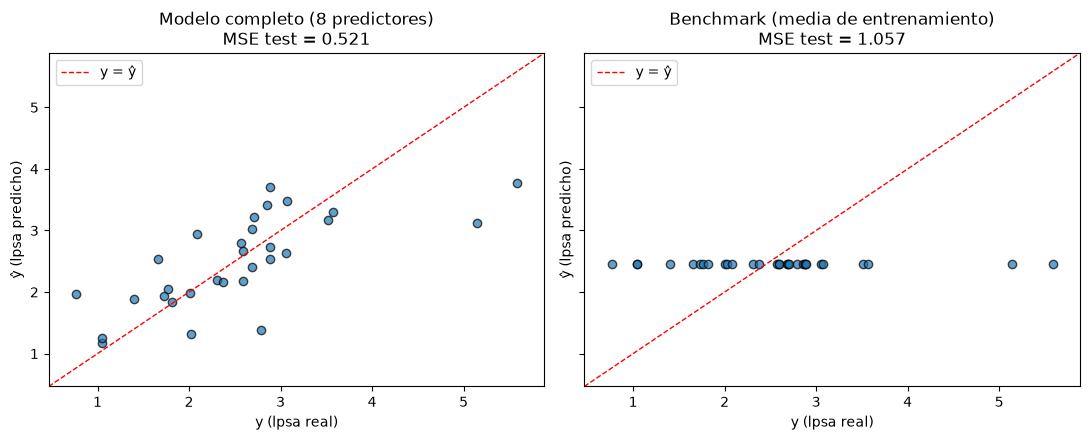

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)

for ax, y_hat, title, err in zip(
    axes,
    [y_pred_full, y_pred_benchmark],
    ["Modelo completo (8 predictores)", "Benchmark (media de entrenamiento)"],
    [test_error_full, test_error_benchmark],
):
    ax.scatter(y_test, y_hat, alpha=0.7, edgecolor="k")
    lims = [min(y_test.min(), y_hat.min()) - 0.3, max(y_test.max(), y_hat.max()) + 0.3]
    ax.plot(lims, lims, "r--", lw=1, label="y = ŷ")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("y (lpsa real)"); ax.set_ylabel("ŷ (lpsa predicho)")
    ax.set_title(f"{title}\nMSE test = {err:.3f}")
    ax.legend()

plt.tight_layout()
plt.show()


---

**Ejercicio:** Utilizando el dataset de *Prostate Cancer*:
1. Implementar un estimador de cuadrados mínimos con descenso por gradiente estocástico. Utilizar una tasa de aprendizaje $\eta = 0.001$ y un número de iteraciones $iter = 10000$. Graficar la evolución de cada coeficiente $\beta_j$ en función de las iteraciones y, en el mismo gráfico, comparar con los resultados obtenidos previamente o en el libro. **Algunas recomendaciones**: no olvidar escalar los predictores e iniciializar los coeficientes $\beta$ a partir de una distribución normal con media cero y varianza uno.
1. Probar diferentes tasas de aprendizaje y número de iteraciones. ¿Qué ocurre si la tasa de aprendizaje es muy baja? ¿Y si es muy alta? ¿Qué ocurre si el número de iteraciones es muy bajo? ¿Y si es muy alto?
1. Probar diferentes inicializaciones de los coeficientes $\beta_j$. ¿Qué ocurre si se inicializan todos en cero? ¿Y si se inicializan en valores aleatorios?
1. Pensar e investigar cómo se podría mejorar este algoritmo. En particular, considerar condiciones de parada y técnicas por *batch*. No es necesario implementar ninguna de esas mejoras, pero sí pensar en cómo se podrían implementar y qué ventajas tendrían.


#### Resolución

**4.1 Implementación de SGD**

Para el modelo lineal $\hat y_i = \beta^Tx_i$ (con $x_i$ incluyendo el 1 del intercept) y costo $RSS(\beta)=\sum_i(y_i-\beta^Tx_i)^2$, el gradiente estocástico usa, en cada iteración, el gradiente calculado con **una única observación** $i$ elegida al azar (con reposición):

$$\nabla_\beta \, (y_i - \beta^Tx_i)^2 = -2\,(y_i - \beta^Tx_i)\,x_i \qquad\Longrightarrow\qquad \beta \leftarrow \beta + 2\eta\,(y_i - \beta^Tx_i)\,x_i$$

Los predictores se estandarizan (media 0, varianza 1) antes de correr el algoritmo — de lo contrario, variables en escalas muy distintas generan curvaturas muy distintas del costo en cada dirección y el gradiente descendente estocástico converge muy lentamente o diverge.

In [11]:
def sgd_least_squares(X, y, eta=0.001, n_iter=10000, beta_init=None, seed=0):
    '''Descenso por gradiente estocástico para mínimos cuadrados.
    X: matriz de diseño (ya con columna de 1's), y: respuesta.
    Devuelve el historial de beta en cada iteración (shape: (n_iter+1, p+1)).
    '''
    rng = np.random.default_rng(seed)
    N, p1 = X.shape
    if beta_init is None:
        beta = rng.normal(loc=0.0, scale=1.0, size=p1)
    else:
        beta = beta_init.copy()

    history = np.zeros((n_iter + 1, p1))
    history[0] = beta
    for t in range(1, n_iter + 1):
        i = rng.integers(0, N)
        x_i, y_i = X[i], y[i]
        grad_i = -2.0 * (y_i - x_i @ beta) * x_i
        beta = beta - eta * grad_i
        history[t] = beta
    return beta, history

beta_sgd, history_sgd = sgd_least_squares(X_train_sm, y_train, eta=0.001, n_iter=10000, seed=0)

coef_names = ["Intercept"] + predictors
pd.DataFrame({
    "OLS (numpy)": beta_np,
    "SGD (10000 it., eta=0.001)": beta_sgd,
    "diff": beta_np - beta_sgd,
}, index=coef_names).round(4)


,OLS (numpy),"SGD (10000 it., eta=0.001)",diff
Intercept,2.4523,2.4576,-0.0053
lcavol,0.7164,0.6597,0.0567
lweight,0.2926,0.3097,-0.0171
age,-0.1425,-0.1829,0.0404
lbph,0.2120,0.1792,0.0328
svi,0.3096,0.2931,0.0165
lcp,-0.2890,-0.2391,-0.0499
gleason,-0.0209,-0.0099,-0.0111
pgg45,0.2773,0.2318,0.0455


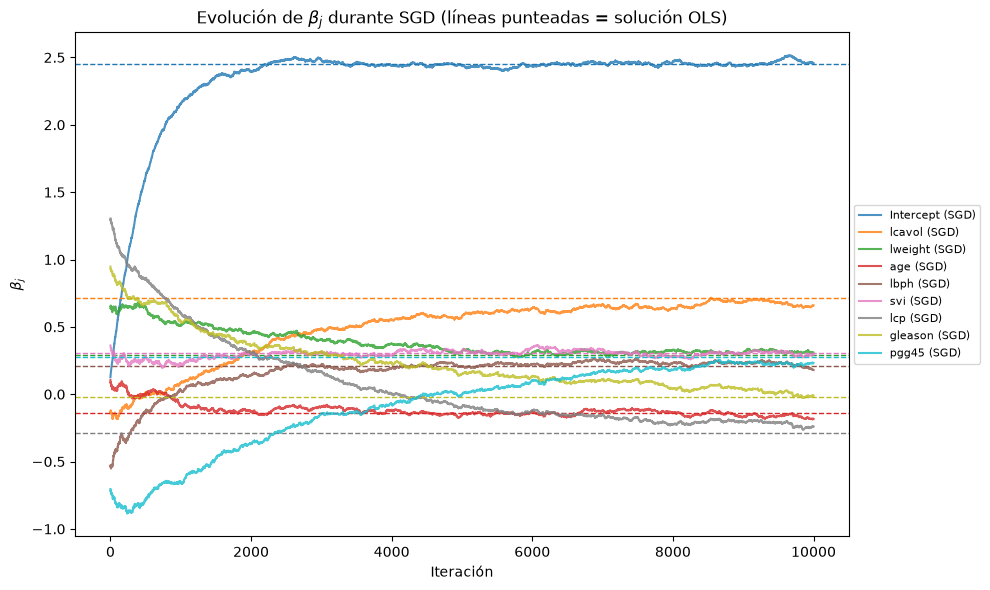

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
iters = np.arange(history_sgd.shape[0])
colors = plt.cm.tab10(np.linspace(0, 1, len(coef_names)))

for j, name in enumerate(coef_names):
    ax.plot(iters, history_sgd[:, j], color=colors[j], alpha=0.8, label=f"{name} (SGD)")
    ax.axhline(beta_np[j], color=colors[j], ls="--", lw=1)

ax.set_xlabel("Iteración")
ax.set_ylabel(r"$\beta_j$")
ax.set_title(r"Evolución de $\beta_j$ durante SGD (líneas punteadas = solución OLS)")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
plt.tight_layout()
plt.show()


Con $\eta=0.001$ y $10000$ iteraciones, las curvas de cada $\beta_j$ **convergen y oscilan alrededor** del valor de mínimos cuadrados obtenido con la fórmula cerrada (líneas punteadas), lo cual confirma que el SGD está aproximando correctamente la solución óptima. Las oscilaciones remanentes son inherentes al SGD: al usar el gradiente ruidoso de una sola observación por paso (en vez del gradiente completo), el algoritmo nunca "se asienta" exactamente en el mínimo con una tasa de aprendizaje constante, sino que fluctúa en un entorno de él.

**4.2 Efecto de la tasa de aprendizaje y del número de iteraciones**

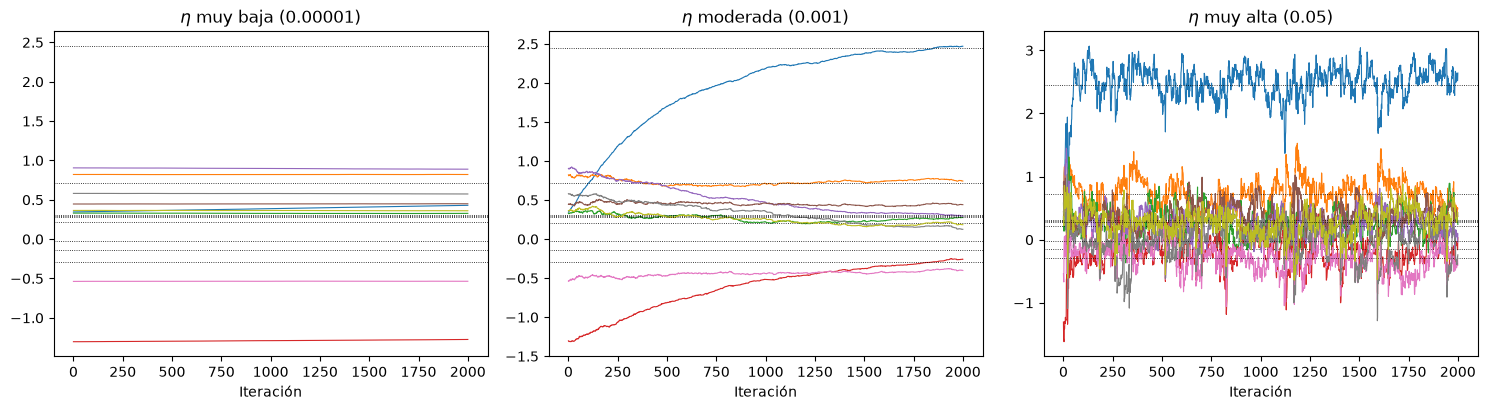

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=False)

etas = [0.00001, 0.001, 0.05]
titles = [r"$\eta$ muy baja (0.00001)", r"$\eta$ moderada (0.001)", r"$\eta$ muy alta (0.05)"]

for ax, eta, title in zip(axes, etas, titles):
    _, hist = sgd_least_squares(X_train_sm, y_train, eta=eta, n_iter=2000, seed=1)
    for j in range(hist.shape[1]):
        ax.plot(hist[:, j], lw=0.8)
        ax.axhline(beta_np[j], color="k", ls=":", lw=0.6)
    ax.set_title(title)
    ax.set_xlabel("Iteración")
plt.tight_layout()
plt.show()


- **Tasa de aprendizaje muy baja**: los pasos son diminutos, por lo que los coeficientes se mueven muy lentamente desde su inicialización y, en un número finito de iteraciones, **no alcanzan a converger** a la solución óptima (subajuste por optimización incompleta).
- **Tasa de aprendizaje muy alta**: los pasos son tan grandes que el algoritmo **sobrepasa el mínimo repetidamente**, generando oscilaciones de amplitud creciente o divergencia franca (los coeficientes "explotan").
- **Número de iteraciones muy bajo**: aunque $\eta$ sea razonable, si se detiene el algoritmo demasiado pronto los coeficientes no llegan a acercarse lo suficiente al óptimo (equivalente, en cierto sentido, a "no entrenar lo suficiente").
- **Número de iteraciones muy alto**: con $\eta$ razonable, iterar de más no perjudica el resultado en cuadrados mínimos (el problema es convexo, no hay sobreajuste "temporal" como en otros modelos), aunque sí implica más costo computacional; con $\eta$ fija, más allá de cierto punto solo se sigue oscilando alrededor del óptimo sin mejorar apreciablemente (por eso en la práctica conviene reducir $\eta$ con las iteraciones, ver 4.4).

**4.3 Efecto de la inicialización de $\beta$**

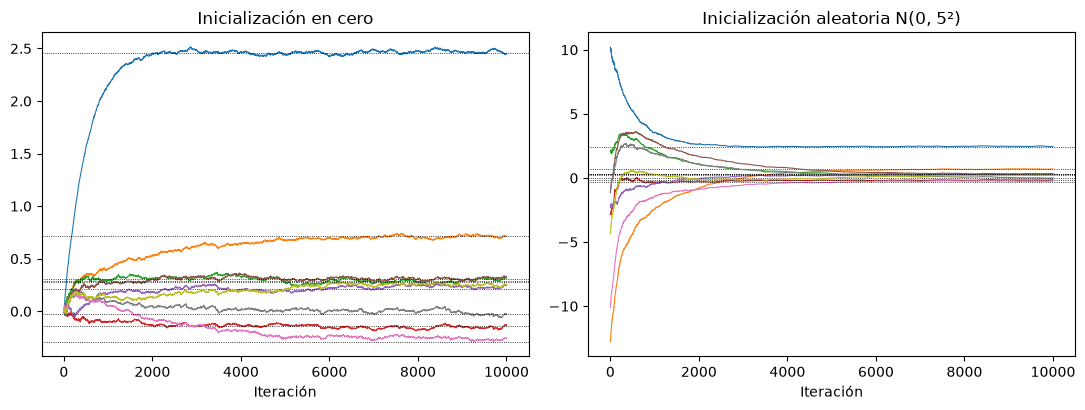

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

_, hist_zero = sgd_least_squares(X_train_sm, y_train, eta=0.001, n_iter=10000,
                                  beta_init=np.zeros(X_train_sm.shape[1]), seed=2)
_, hist_rand = sgd_least_squares(X_train_sm, y_train, eta=0.001, n_iter=10000,
                                  beta_init=np.random.default_rng(3).normal(0, 5, X_train_sm.shape[1]), seed=2)

for ax, hist, title in zip(axes, [hist_zero, hist_rand],
                            ["Inicialización en cero", "Inicialización aleatoria N(0, 5²)"]):
    for j in range(hist.shape[1]):
        ax.plot(hist[:, j], lw=0.8)
        ax.axhline(beta_np[j], color="k", ls=":", lw=0.6)
    ax.set_title(title)
    ax.set_xlabel("Iteración")
plt.tight_layout()
plt.show()


- **Inicialización en cero**: para mínimos cuadrados (problema convexo, sin simetrías que "atrapen" al algoritmo, a diferencia por ejemplo de redes neuronales) esto no es problemático — el algoritmo igual converge a la misma región óptima, solo cambia el punto de partida del recorrido.
- **Inicialización aleatoria** (sea $N(0,1)$ u otra escala): tampoco afecta la convergencia final, aunque si la escala inicial es muy grande respecto de los coeficientes óptimos, se necesitan más iteraciones (o una $\eta$ mayor al principio) para que el algoritmo recorra la distancia hasta la zona óptima. En modelos convexos como este, la inicialización afecta principalmente la **velocidad** de convergencia, no si converge o no.

**4.4 Posibles mejoras al algoritmo**

- **Condición de parada (criterio de convergencia)**: en vez de fijar de antemano un número de iteraciones, se puede detener el algoritmo cuando la mejora del costo (o la norma del cambio en $\beta$) entre iteraciones sucesivas cae por debajo de una tolerancia $\varepsilon$, o cuando el gradiente (o una estimación suavizada de él, dado el ruido) tiene norma pequeña. Ventaja: evita iterar de más innecesariamente (ahorro de cómputo) y evita detenerse antes de converger si el problema requiere más pasos.
- **Tasa de aprendizaje decreciente (*learning rate schedule*)**: usar $\eta_t = \eta_0 / (1 + \lambda t)$ o similar, de forma que los pasos sean grandes al principio (convergencia rápida) y pequeños al final (menor oscilación alrededor del óptimo, mayor precisión final). Es una forma estándar de resolver el "trade-off" entre velocidad de convergencia y precisión final que se observó en 4.2.
- **Mini-batches**: en lugar de usar una única observación (SGD puro) o el dataset completo (descenso por gradiente batch), se puede promediar el gradiente sobre un subconjunto pequeño (*mini-batch*) de tamaño $m$ elegido al azar en cada paso. Ventajas: reduce la varianza del gradiente estimado respecto de SGD puro (menos oscilación, convergencia más estable) sin pagar el costo computacional completo de recorrer todo el dataset en cada paso (como sí ocurre en *batch gradient descent*); además permite aprovechar operaciones vectorizadas/paralelismo de hardware (GPU) de forma mucho más eficiente que actualizar con una sola observación a la vez.
- **Momentum / métodos adaptativos** (Adam, RMSProp, etc.): acumulan información de gradientes pasados para acelerar la convergencia en direcciones consistentes y amortiguar oscilaciones, adaptando efectivamente la tasa de aprendizaje por parámetro.

---

**Ejercicio:** Ir a la documentación y al código de la [regresión lineal en Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html). Familiarizarse con ella. Leer el comentario acerca de la implementación en "Notes". Luego, ir al código y ver cómo está implementado el `.fit()`. ¿Qué diferencias hay con lo visto?


#### Resolución

La documentación de `sklearn.linear_model.LinearRegression` indica en la sección *Notes*: *"From the implementation point of view, this is just plain Ordinary Least Squares (`scipy.linalg.lstsq`) or Non Negative Least Squares (`scipy.optimize.nnls`) wrapped as a predictor object."*

Revisando el código fuente (`sklearn/linear_model/_base.py`, método `LinearRegression.fit`), el ajuste **no** resuelve las ecuaciones normales $\hat\beta=(X^TX)^{-1}X^Ty$ como hicimos "a mano" con `numpy`. En cambio, delega en `scipy.linalg.lstsq`, que internamente utiliza una **descomposición en valores singulares (SVD)** de $X$ (a través de rutinas LAPACK como `gelsd`) para resolver el problema de mínimos cuadrados.

Diferencias principales respecto de lo visto:

1. **Estabilidad numérica**: formar $X^TX$ explícitamente (como hicimos con `numpy`) eleva al cuadrado el número de condición de $X$, lo que puede amplificar errores de redondeo cuando los predictores están (casi) colineales. La SVD trabaja directamente sobre $X$ y evita ese paso, siendo numéricamente más estable y robusta ante **multicolinealidad** o predictores redundantes.
2. **Matrices no invertibles / rango deficiente**: si $X^TX$ es singular (por ejemplo, $p+1 > N$, o predictores linealmente dependientes), la fórmula de ecuaciones normales no se puede aplicar directamente. `lstsq` vía SVD siempre devuelve una solución (la de norma mínima entre las que minimizan el RSS) aunque $X$ no tenga rango completo, gracias a la pseudo-inversa de Moore-Penrose $X^+ = V\Sigma^+U^T$.
3. **Costo computacional**: para $X$ de $N\times(p+1)$, calcular $X^TX$ y su inversa cuesta $O(Np^2 + p^3)$, mientras que la SVD de $X$ cuesta $O(Np^2)$ (para $N\ge p$) con una constante algo mayor — en la práctica, ambas son viables para $p$ moderado, pero la vía SVD es la preferida quirúrgicamente por su estabilidad.
4. **Centrado, no estandarizado**: `LinearRegression` (con `fit_intercept=True`, el default) centra $X$ e $y$ restando sus medias antes de resolver el problema (y luego recupera el intercept), pero **no** estandariza automáticamente la escala de las variables (a diferencia de lo que hicimos "a mano" siguiendo al libro) — queda a cargo del usuario escalar los predictores si se desea (p.ej. con `StandardScaler`).

En definitiva, es exactamente el mismo problema de optimización (minimizar $RSS(\beta)$) y, en un caso de rango completo bien condicionado, produce la **misma solución matemática** que las ecuaciones normales; solo cambia el algoritmo numérico usado para resolverlo.

In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_std, y_train)

sklearn_beta = np.concatenate([[lr.intercept_], lr.coef_])

pd.DataFrame({
    "OLS (numpy, ecs. normales)": beta_np,
    "sklearn LinearRegression (SVD)": sklearn_beta,
    "diff": beta_np - sklearn_beta,
}, index=coef_names).round(10)


,"OLS (numpy, ecs. normales)",sklearn LinearRegression (SVD),diff
Intercept,2.4523,2.4523,0.0
lcavol,0.7164,0.7164,-0.0
lweight,0.2926,0.2926,-0.0
age,-0.1425,-0.1425,-0.0
lbph,0.2120,0.2120,0.0
svi,0.3096,0.3096,-0.0
lcp,-0.2890,-0.2890,0.0
gleason,-0.0209,-0.0209,-0.0
pgg45,0.2773,0.2773,-0.0


Como se observa, ambas implementaciones producen coeficientes idénticos hasta errores de redondeo de punto flotante (del orden de $10^{-14}$–$10^{-15}$): la diferencia es puramente algorítmica/numérica, no matemática.

---

**Ejercicio:** Ir a la documentación de la [regresión Ridge en Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge). Leer acerca de los *solvers* disponibles y sus diferencias. ¿Cómo se relacional con lo visto? Volveremos sobre este ejercicio.

#### Resolución

La regresión Ridge agrega una penalización $L_2$ al RSS: $RSS_{ridge}(\beta) = \|y-X\beta\|^2 + \alpha\|\beta\|^2$, cuya solución cerrada es $\hat\beta_{ridge} = (X^TX + \alpha I)^{-1}X^Ty$ — una generalización directa de la fórmula de mínimos cuadrados vista antes, donde sumar $\alpha I$ (con $\alpha>0$) hace que la matriz a invertir sea siempre definida positiva (y por lo tanto invertible), incluso cuando $X^TX$ es singular o está mal condicionada (predictores colineales, o $p>N$).

`sklearn.linear_model.Ridge` expone el parámetro `solver` con varias opciones, cada una relacionada con un método distinto de resolver ese mismo problema (o una variante equivalente):

- **`'svd'`**: usa la descomposición en valores singulares de $X$ para calcular la solución vía la pseudo-inversa, de forma análoga a `lstsq` en `LinearRegression` (ejercicio anterior), pero incorporando la penalización $\alpha$ mediante los valores singulares (filtrando/atenuando las direcciones de menor varianza). Es el más estable numéricamente, aunque más costoso.
- **`'cholesky'`**: resuelve directamente el sistema lineal $(X^TX+\alpha I)\beta = X^Ty$ (las "ecuaciones normales" con regularización, exactamente lo que derivamos a mano en el Ejercicio 2/3) mediante una factorización de Cholesky de $X^TX+\alpha I$, aprovechando que esa matriz es simétrica definida positiva. Es más rápido que SVD pero algo menos robusto si $X^TX$ está muy mal condicionada (aunque el propio $\alpha I$ ya mejora el condicionamiento).
- **`'lsqr'`**: usa el algoritmo iterativo *LSQR* (basado en bidiagonalización de Lanczos) para resolver el problema de mínimos cuadrados regularizado sin formar $X^TX$ explícitamente; suele ser la opción más rápida para datasets grandes y dispersos (*sparse*).
- **`'sparse_cg'`**: usa gradiente conjugado (*Conjugate Gradient*), un método iterativo, aplicado al sistema regularizado; es adecuado para matrices $X$ grandes y dispersas, evitando también construir $X^TX$ en memoria.
- **`'sag'` / `'saga'`** (*Stochastic Average Gradient* [Descent]): son variantes de **descenso por gradiente estocástico** con una modificación clave — en vez de usar solo el gradiente de la observación actual (como el SGD "puro" que implementamos en el Ejercicio 3), mantienen un promedio de los últimos gradientes calculados para cada observación, lo que reduce drásticamente la varianza del gradiente estimado y logra una convergencia mucho más rápida y estable que el SGD ingenuo. `'saga'` es una variante de `'sag'` que además admite penalización $L_1$ (relevante para Lasso/ElasticNet) y suele converger algo más rápido. Son la opción recomendada para $N$ muy grande, donde ni siquiera resolver el sistema lineal (SVD/Cholesky) es viable en memoria/tiempo.
- **`'lbfgs'`**: método cuasi-Newton de optimización general (solo disponible cuando se combina con restricciones de no negatividad `positive=True`), que aproxima la matriz Hessiana iterativamente en vez de calcularla exactamente.

**Relación con lo visto en este notebook:**

- `'cholesky'` es, esencialmente, la misma idea de las **ecuaciones normales** que resolvimos "a mano" con `numpy` (Ejercicio 3.3), extendida con el término de regularización $\alpha I$.
- `'svd'` es la misma idea que usa `LinearRegression` internamente (Ejercicio 5), adaptada al caso regularizado.
- `'sag'`/`'saga'` son la contraparte *productiva* y mejorada del **SGD** que implementamos desde cero en el Ejercicio 4: mismo principio (actualizar $\beta$ usando gradientes de observaciones individuales o pequeños subconjuntos), pero con las mejoras de reducción de varianza que discutimos conceptualmente en el punto 4.4 (promediar gradientes en vez de usar uno solo y ruidoso en cada paso).

Es decir, los distintos *solvers* de Ridge no son más que **distintas formas de resolver numéricamente el mismo problema de optimización convexo** — la elección depende del tamaño y la estructura (denso/disperso) del dataset, y de si se puede o no formar y factorizar $X^TX$ de forma práctica.